In [2]:
import warnings
import pandas as pd
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import (
    PowerTransformer,
    KBinsDiscretizer,
    TargetEncoder)
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.feature_selection import SelectKBest
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE

In [2]:
train = pd.read_csv('./data/final_proj_data.csv')
valid = pd.read_csv('./data/final_proj_test.csv')
train

,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var222,Var223,Var224,Var225,Var226,Var227,Var228,Var229,Var230,y
0,NaN,NaN,NaN,NaN,NaN,812.0,14.0,NaN,NaN,NaN,...,catzS2D,jySVZNlOJy,NaN,xG3x,Aoh3,ZI9m,ib5G6X1eUxUn6,mj86,NaN,0
1,NaN,NaN,NaN,NaN,NaN,2688.0,7.0,NaN,NaN,NaN,...,i06ocsg,LM8l689qOp,NaN,kG3k,WqMG,RAYp,55YFVY9,mj86,NaN,0
2,NaN,NaN,NaN,NaN,NaN,1015.0,14.0,NaN,NaN,NaN,...,P6pu4Vl,LM8l689qOp,NaN,kG3k,Aoh3,ZI9m,R4y5gQQWY8OodqDV,am7c,NaN,0
3,NaN,NaN,NaN,NaN,NaN,168.0,0.0,NaN,NaN,NaN,...,BNrD3Yd,LM8l689qOp,NaN,NaN,FSa2,RAYp,F2FyR07IdsN7I,NaN,NaN,0
4,NaN,NaN,NaN,NaN,NaN,14.0,0.0,NaN,NaN,NaN,...,3B1QowC,LM8l689qOp,NaN,NaN,WqMG,RAYp,F2FyR07IdsN7I,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,NaN,NaN,NaN,NaN,NaN,714.0,7.0,NaN,NaN,NaN,...,CE7uk3u,jySVZNlOJy,NaN,NaN,FSa2,RAYp,F2FyR07IdsN7I,NaN,NaN,0
9996,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,NaN,...,UpJuOS_,LM8l689qOp,NaN,NaN,TNEC,6fzt,F2FcTt7IdMT_v,NaN,NaN,0
9997,NaN,NaN,NaN,NaN,NaN,1526.0,7.0,NaN,NaN,NaN,...,Ff09Jxo,LM8l689qOp,NaN,NaN,FSa2,RAYp,F2FyR07IdsN7I,NaN,NaN,0
9998,NaN,NaN,NaN,NaN,NaN,1267.0,14.0,NaN,NaN,NaN,...,catzS2D,LM8l689qOp,NaN,kG3k,453m,ZI9m,TCU50_Yjmm6GIBZ0lL_,am7c,NaN,0


In [3]:
# target = train.pop('y')

In [4]:
train

,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var222,Var223,Var224,Var225,Var226,Var227,Var228,Var229,Var230,y
0,NaN,NaN,NaN,NaN,NaN,812.0,14.0,NaN,NaN,NaN,...,catzS2D,jySVZNlOJy,NaN,xG3x,Aoh3,ZI9m,ib5G6X1eUxUn6,mj86,NaN,0
1,NaN,NaN,NaN,NaN,NaN,2688.0,7.0,NaN,NaN,NaN,...,i06ocsg,LM8l689qOp,NaN,kG3k,WqMG,RAYp,55YFVY9,mj86,NaN,0
2,NaN,NaN,NaN,NaN,NaN,1015.0,14.0,NaN,NaN,NaN,...,P6pu4Vl,LM8l689qOp,NaN,kG3k,Aoh3,ZI9m,R4y5gQQWY8OodqDV,am7c,NaN,0
3,NaN,NaN,NaN,NaN,NaN,168.0,0.0,NaN,NaN,NaN,...,BNrD3Yd,LM8l689qOp,NaN,NaN,FSa2,RAYp,F2FyR07IdsN7I,NaN,NaN,0
4,NaN,NaN,NaN,NaN,NaN,14.0,0.0,NaN,NaN,NaN,...,3B1QowC,LM8l689qOp,NaN,NaN,WqMG,RAYp,F2FyR07IdsN7I,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,NaN,NaN,NaN,NaN,NaN,714.0,7.0,NaN,NaN,NaN,...,CE7uk3u,jySVZNlOJy,NaN,NaN,FSa2,RAYp,F2FyR07IdsN7I,NaN,NaN,0
9996,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,NaN,...,UpJuOS_,LM8l689qOp,NaN,NaN,TNEC,6fzt,F2FcTt7IdMT_v,NaN,NaN,0
9997,NaN,NaN,NaN,NaN,NaN,1526.0,7.0,NaN,NaN,NaN,...,Ff09Jxo,LM8l689qOp,NaN,NaN,FSa2,RAYp,F2FyR07IdsN7I,NaN,NaN,0
9998,NaN,NaN,NaN,NaN,NaN,1267.0,14.0,NaN,NaN,NaN,...,catzS2D,LM8l689qOp,NaN,kG3k,453m,ZI9m,TCU50_Yjmm6GIBZ0lL_,am7c,NaN,0


In [5]:
dtype_counts = train.dtypes.value_counts()
print(dtype_counts)
print(train.shape)


float64    191
object      38
int64        2
Name: count, dtype: int64
(10000, 231)


In [6]:
# Колонки, де всі значення NaN
columns_to_drop = train.columns[train.isna().all()].tolist()
print(f"Колонки для видалення (всі значення NaN): {columns_to_drop}")

# Рядки, де всі значення NaN
rows_to_drop = train[train.isna().all(axis=1)]
print(f"Кількість рядків для видалення (всі значення NaN): {len(rows_to_drop)}")

# Видалити колонки, де всі значення NaN
train = train.dropna(axis=1, how='all')
# Видалити рядки, де всі значення NaN
train = train.dropna(axis=0, how='all')

Колонки для видалення (всі значення NaN): ['Var8', 'Var15', 'Var20', 'Var31', 'Var32', 'Var39', 'Var42', 'Var48', 'Var52', 'Var55', 'Var79', 'Var141', 'Var167', 'Var169', 'Var175', 'Var185', 'Var209', 'Var230']
Кількість рядків для видалення (всі значення NaN): 0


In [7]:
# Крок 1: Створюємо список колонок для видалення
cols_to_drop = []
for col in train.columns:
    # Унікальні значення в колонці без NaN
    unique_values = train[col].dropna().unique()
    # Перевіряємо, чи всі значення в колонці рівні 0
    if set(unique_values) == {0}:  # Якщо унікальні значення - це тільки 0
        cols_to_drop.append(col)

# Крок 2: Виводимо список колонок, які будуть видалені
print("Видаляємо колонки, де всі значення або 0, або NaN:", cols_to_drop)

# Крок 3: Видаляємо ці колонки з датафрейму
train = train.drop(columns=cols_to_drop)


Видаляємо колонки, де всі значення або 0, або NaN: ['Var2', 'Var138']


In [8]:
dtype_counts = train.dtypes.value_counts()
print(dtype_counts)
print(train.shape)

float64    171
object      38
int64        2
Name: count, dtype: int64
(10000, 211)


In [9]:
from scipy.stats import zscore
import pandas as pd
import numpy as np

# 1. Вибираємо float64 колонки з >5 унікальними значеннями
float_cols = train.select_dtypes(include='float64')
selected_cols = [col for col in float_cols.columns if train[col].nunique(dropna=True) > 5]

# 2. Рахуємо z-score
z_df = train[selected_cols].apply(zscore, nan_policy='omit')

# 3. Рахуємо кількість outliers (де |z| > 3)
outlier_report = pd.DataFrame({
    'column': selected_cols,
    'num_outliers': (np.abs(z_df) > 3).sum(),
    'perc_outliers': (np.abs(z_df) > 3).sum() / train.shape[0]
}).sort_values(by='perc_outliers', ascending=False)

outlier_report

,column,num_outliers,perc_outliers
Var35,Var35,290,0.0290
Var134,Var134,222,0.0222
Var163,Var163,215,0.0215
Var132,Var132,213,0.0213
Var78,Var78,212,0.0212
...,...,...,...
Var57,Var57,0,0.0000
Var153,Var153,0,0.0000
Var188,Var188,0,0.0000
Var135,Var135,0,0.0000


In [10]:
# There is no big outlier leave as is

In [11]:
def correlation_with_target(df, target_col='y', dtype='float64', nan_thresh=0.9):
    # Вибір колонок із зазначеним типом і sparsity
    candidate_cols = [
        col for col in df.select_dtypes(include=dtype).columns
        if df[col].isna().mean() > nan_thresh and col != target_col
    ]

    correlations = []
    for col in candidate_cols:
        try:
            corr = df[[col, target_col]].dropna().corr().iloc[0, 1]
        except Exception:
            corr = None
        correlations.append({
            'column': col,
            'nan_ratio': round(df[col].isna().mean(), 3),
            'corr_with_target': round(corr, 4) if corr is not None else None
        })

    return pd.DataFrame(correlations).sort_values(by='corr_with_target', key=lambda x: x.abs(), ascending=False)
# corr_report = correlation_with_target(train, target_col='y', nan_thresh=0.9)
corr_report = correlation_with_target(train, target_col='y', nan_thresh=0.9)
print(corr_report)

     column  nan_ratio  corr_with_target
122  Var180      0.987           -0.1721
113  Var168      0.987           -0.1557
102  Var154      0.987           -0.1549
97   Var147      0.976           -0.1524
116  Var172      0.976           -0.1371
..      ...        ...               ...
21    Var37      0.972           -0.0040
61    Var96      0.973           -0.0029
38    Var62      0.990            0.0021
7     Var12      0.990            0.0011
80   Var118      0.996               NaN

[130 rows x 3 columns]


In [12]:
pd.options.display.max_rows = None

low_card_cols = train.columns[train.nunique() <= 25]

# Виводимо розподіл значень для кожної з цих колонок
for col in low_card_cols:
    print(f"\n=== Column: {col} ({train[col].dtype}) ===")
    print(train[col].value_counts(dropna=False))

pd.reset_option('display.max_rows')


=== Column: Var1 (float64) ===
Var1
NaN      9867
0.0        73
8.0        25
16.0       15
24.0       11
32.0        5
680.0       1
40.0        1
360.0       1
48.0        1
Name: count, dtype: int64

=== Column: Var4 (float64) ===
Var4
NaN    9720
0.0     277
9.0       3
Name: count, dtype: int64

=== Column: Var7 (float64) ===
Var7
7.0     4733
0.0     2631
14.0    1044
NaN     1005
21.0     402
28.0     136
35.0      49
Name: count, dtype: int64

=== Column: Var11 (float64) ===
Var11
NaN     9734
8.0      254
16.0      11
32.0       1
Name: count, dtype: int64

=== Column: Var12 (float64) ===
Var12
NaN       9896
0.0         53
16.0        18
8.0         15
24.0         7
32.0         3
104.0        2
128.0        1
112.0        1
48.0         1
1184.0       1
72.0         1
40.0         1
Name: count, dtype: int64

=== Column: Var14 (float64) ===
Var14
NaN     9734
0.0      248
4.0        4
6.0        3
2.0        3
18.0       2
14.0       2
38.0       1
8.0        1
16.0       

In [13]:
low_card_object_cols = [
    col for col in train.select_dtypes(include='object').columns
]

# Виводимо розподіл значень
for col in low_card_object_cols:
    print(f"\n=== Column: {col} ({train[col].dtype}) ===")
    print(train[col].value_counts(dropna=False))



=== Column: Var191 (object) ===
Var191
NaN     9830
r__I     170
Name: count, dtype: int64

=== Column: Var192 (object) ===
Var192
8I1r4RXXnK    92
0vimfo8zhV    91
hSovyx7IEC    83
1GdOj1KXzC    83
75lr4RXktW    82
              ..
RzPTmBQZiT     1
ohYOj17ejg     1
2AArEyQtC3     1
dRaq9atbb6     1
crIgUHf2Df     1
Name: count, Length: 298, dtype: int64

=== Column: Var193 (object) ===
Var193
RO12                                        6965
2Knk1KF                                     1574
AERks4l                                      476
g62hiBSaKg                                   136
e6CkoqApVR                                   126
rEUOq2QD1qfkRr6qpua                           96
LrdZy8QqgUfkVShG                              93
eSGpMwS8zSGgq_trOpckZ5                        92
onTuEhrJJQy_H3IHkZku5AFczhYGqxJ890            57
vuPfq6YcbX                                    38
LrdVolaSGUfkVeWC                              37
w9ygS99Qp_                                    33
TW8dXluYzKpktZ

In [14]:
def analyze_categorical_cardinality(df, max_unique=100, card_ratio_thresh=0.1, rare_thresh=0.01):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    result = []

    for col in cat_cols:
        n_unique = df[col].nunique(dropna=True)
        cardinality_ratio = n_unique / df.shape[0]

        value_counts = df[col].value_counts(normalize=True, dropna=True)
        rare_pct = (value_counts < rare_thresh).sum() / n_unique if n_unique > 0 else 0

        # Класифікація
        if n_unique <= 10:
            level = "low"
        elif n_unique <= max_unique:
            level = "medium"
        else:
            level = "high"

        # Рекомендація
        if level == "low":
            recommendation = "keep"
        elif level == "medium":
            recommendation = "merge_rare" if rare_pct > 0.5 else "keep"
        else:  # high
            if cardinality_ratio > card_ratio_thresh:
                recommendation = "drop"
            else:
                recommendation = "target_encode"

        result.append({
            'column': col,
            'n_unique': n_unique,
            'cardinality_ratio': round(cardinality_ratio, 3),
            'rare_pct': round(rare_pct, 3),
            'cardinality_level': level,
            'recommendation': recommendation
        })

    return pd.DataFrame(result).sort_values(by='cardinality_level')
cardinality_report = analyze_categorical_cardinality(train)
cardinality_report

,column,n_unique,cardinality_ratio,rare_pct,cardinality_level,recommendation
9,Var200,4478,0.448,1.000,high,drop
1,Var192,297,0.030,1.000,high,target_encode
24,Var216,977,0.098,0.982,high,target_encode
25,Var217,5529,0.553,1.000,high,drop
6,Var197,185,0.018,0.935,high,target_encode
7,Var198,2100,0.210,0.998,high,drop
8,Var199,1850,0.185,0.992,high,drop
22,Var214,4478,0.448,1.000,high,drop
30,Var222,2100,0.210,0.998,high,drop
11,Var202,3802,0.380,1.000,high,drop


In [15]:
from category_encoders import TargetEncoder
# Вибираємо колонки для таргет-енкодингу
target_enc_cols = cardinality_report.query("recommendation == 'target_encode'")['column'].tolist()

print("Енкодимо з TargetEncoder колонки:", target_enc_cols)
# Створюємо енкодер
encoder = TargetEncoder(cols=target_enc_cols)
# Навчаємо та трансформуємо
train[target_enc_cols] = encoder.fit_transform(train[target_enc_cols], train['y'])

Енкодимо з TargetEncoder колонки: ['Var192', 'Var216', 'Var197']


In [16]:
cols_to_drop = cardinality_report.query("recommendation == 'drop'")['column'].tolist()
train = train.drop(columns=cols_to_drop)
print("Видаляємо колонки, де з високим рівнем варіативності:", cols_to_drop)

Видаляємо колонки, де з високим рівнем варіативності: ['Var200', 'Var217', 'Var198', 'Var199', 'Var214', 'Var222', 'Var202', 'Var220']


In [17]:
# Вибираємо всі object-типи колонок
object_cols = train.select_dtypes(include='object').columns
print("Робимо one-hot-encoding для всіх категоріальних колонок:", object_cols)
# One-hot encoding (з NaN → окрема колонка)
train = pd.get_dummies(train, columns=object_cols, dummy_na=True, drop_first=False)

Робимо one-hot-encoding для всіх категоріальних колонок: Index(['Var191', 'Var193', 'Var194', 'Var195', 'Var196', 'Var201', 'Var203',
       'Var204', 'Var205', 'Var206', 'Var207', 'Var208', 'Var210', 'Var211',
       'Var212', 'Var213', 'Var215', 'Var218', 'Var219', 'Var221', 'Var223',
       'Var224', 'Var225', 'Var226', 'Var227', 'Var228', 'Var229'],
      dtype='object')


In [18]:
train

,Var1,Var3,Var4,Var5,Var6,Var7,Var9,Var10,Var11,Var12,...,Var228_iyHGyLCEkQ,Var228_n1OBWGkV3fbsHR75taC,Var228_r_7E,Var228_xwM2aC7IdeMC0,Var228_nan,Var229_am7c,Var229_mj86,Var229_oJmt,Var229_sk2h,Var229_nan
0,NaN,NaN,NaN,NaN,812.0,14.0,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,True,False,False,False
1,NaN,NaN,NaN,NaN,2688.0,7.0,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,True,False,False,False
2,NaN,NaN,NaN,NaN,1015.0,14.0,NaN,NaN,NaN,NaN,...,False,False,False,False,False,True,False,False,False,False
3,NaN,NaN,NaN,NaN,168.0,0.0,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,True
4,NaN,NaN,NaN,NaN,14.0,0.0,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,NaN,NaN,NaN,NaN,714.0,7.0,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,True
9996,0.0,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN,0.0,...,False,False,False,False,False,False,False,False,False,True
9997,NaN,NaN,NaN,NaN,1526.0,7.0,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,True
9998,NaN,NaN,NaN,NaN,1267.0,14.0,NaN,NaN,NaN,NaN,...,False,False,False,False,False,True,False,False,False,False


In [19]:
dtype_counts = train.dtypes.value_counts()
print(dtype_counts)
print(train.shape)

bool       408
float64    174
int64        2
Name: count, dtype: int64
(10000, 584)


In [20]:
# train.select_dtypes(include='float64').describe()

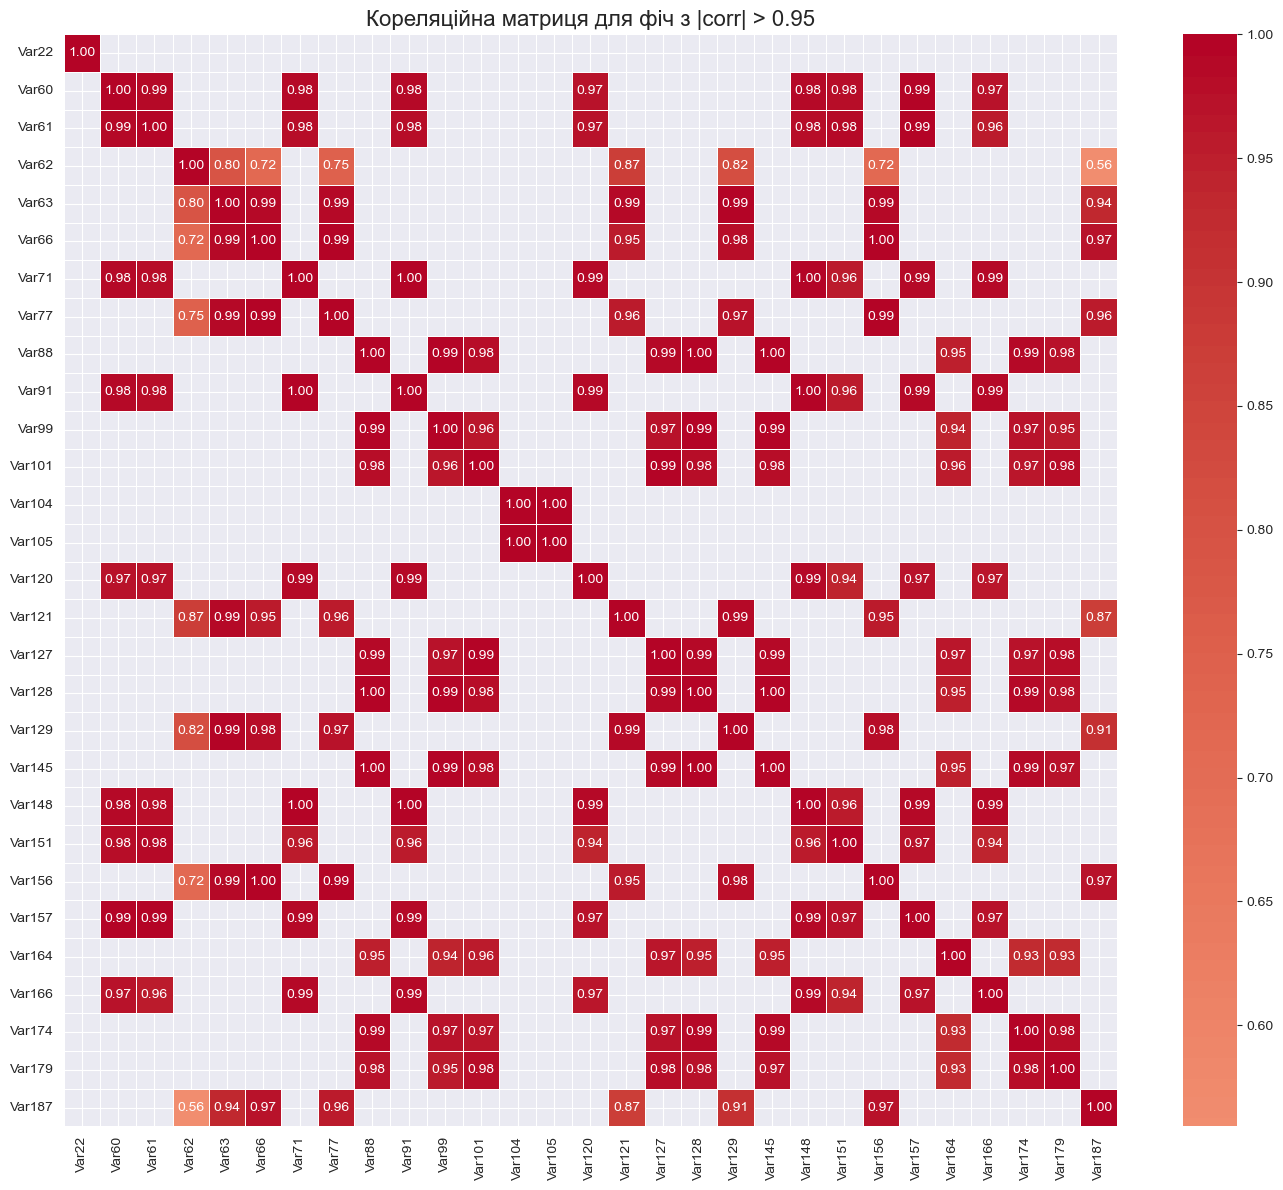

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = train.copy()
# Вибираємо числові фічі
X = df.drop(columns='y')
X_num = X.select_dtypes(include=[np.number])

# Обчислюємо абсолютну кореляційну матрицю
corr_matrix = X_num.corr().abs()

# Фільтруємо верхній трикутник матриці
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Вибираємо фічі, де є хоча б одна кореляція > threshold
threshold = 0.95
high_corr_cols = [column for column in upper.columns if any(upper[column] > threshold)]

# Побудова графіку
plt.figure(figsize=(14, 12))
sns.heatmap(
    X_num[high_corr_cols].corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    center=0
)
plt.title(f"Кореляційна матриця для фіч з |corr| > {threshold}", fontsize=16)
plt.tight_layout()
plt.show()

In [43]:
def drop_highly_correlated_features(df, threshold=0.95, exclude_target='y'):
    # 1. Вибір числових колонок (без таргету)
    df_num = df.drop(columns=exclude_target, errors='ignore').select_dtypes(include=[np.number])

    # 2. Розрахунок кореляційної матриці
    corr_matrix = df_num.corr().abs()

    # 3. Верхній трикутник (щоб уникнути дублювання)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # 4. Вибір колонок до видалення
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

    print(f"🔻 {len(to_drop)} колонок буде видалено через високу кореляцію > {threshold}:")
    print(to_drop)

    # 5. Видалити з датафрейму
    return df.drop(columns=to_drop, errors='ignore'), to_drop

df_cleaned, _ = drop_highly_correlated_features(df=df)
print(df.shape)
print(df_cleaned.shape)

🔻 29 колонок буде видалено через високу кореляцію > 0.95:
['Var22', 'Var60', 'Var61', 'Var62', 'Var63', 'Var66', 'Var71', 'Var77', 'Var88', 'Var91', 'Var99', 'Var101', 'Var104', 'Var105', 'Var120', 'Var121', 'Var127', 'Var128', 'Var129', 'Var145', 'Var148', 'Var151', 'Var156', 'Var157', 'Var164', 'Var166', 'Var174', 'Var179', 'Var187']
(10000, 231)
(10000, 202)


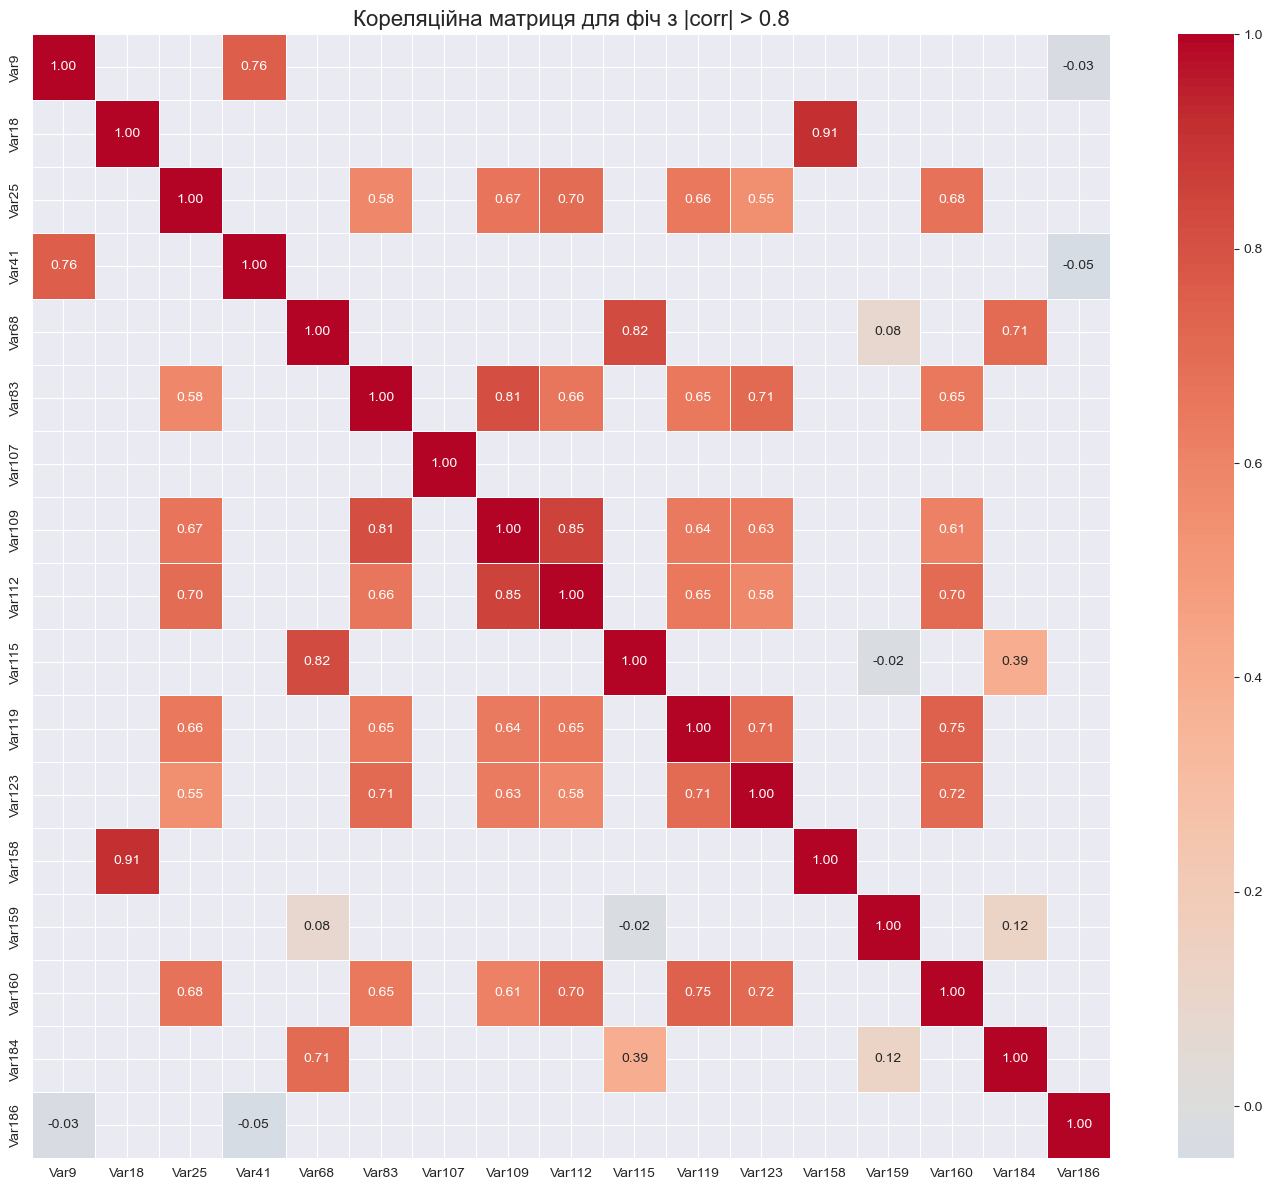

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Вибираємо числові фічі
X = df_cleaned
X_num = X.select_dtypes(include=[np.number])

# Обчислюємо абсолютну кореляційну матрицю
corr_matrix = X_num.corr().abs()

# Фільтруємо верхній трикутник матриці
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Вибираємо фічі, де є хоча б одна кореляція > threshold
threshold = 0.8
high_corr_cols = [column for column in upper.columns if any(upper[column] > threshold)]

# Побудова графіку
plt.figure(figsize=(14, 12))
sns.heatmap(
    X_num[high_corr_cols].corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    center=0
)
plt.title(f"Кореляційна матриця для фіч з |corr| > {threshold}", fontsize=16)
plt.tight_layout()
plt.show()

In [96]:
from competition.eda.CategoryFeatures import suggest_encoding_strategies
categorical_features = train.select_dtypes(include=['object', 'category']).columns
report = suggest_encoding_strategies(train, categorical_features, 'y')
report


--- Аналіз та Рекомендації для Категоріальних Фіч ---
Поріг низької кардинальності (OHE): <= 20
Поріг дуже високої кардинальності (Drop/Native): > 1000
Поріг ID-подібності: > 95.0% унікальних
Поріг пропущених значень для Drop: > 70.0%
Поріг сили зв'язку (Регресія): > 0.0500
Поріг сили зв'язку (Класифікація): > 0.0500
--------------------------------------------------

Аналіз фічі: 'Var191'
  Пропущено: 98.30%
  РЕКОМЕНДАЦІЯ: Drop (Дуже багато пропущених: > 70.0%)

Аналіз фічі: 'Var192'
  Пропущено: 0.79%
  Кардинальність: 298
  [Аналіз зв'язку Var192-y (регр.)] StdDev середніх: 0.2493
  РЕКОМЕНДАЦІЯ: TE (Target Encoding - Обережно!) / XGBoost-Native (Висока кардинальність, є зв'язок з target)

Аналіз фічі: 'Var193'
  Пропущено: 0.00%
  Кардинальність: 40
  [Аналіз зв'язку Var193-y (регр.)] StdDev середніх: 0.0689
  РЕКОМЕНДАЦІЯ: TE (Target Encoding - Обережно!) / XGBoost-Native (Висока кардинальність, є зв'язок з target)

Аналіз фічі: 'Var194'
  Пропущено: 74.67%
  РЕКОМЕНДАЦІЯ: Drop 

{'Var191': 'Drop (High Missing %: 98.30%)',
 'Var192': 'TE (Target Encoding - Обережно!) / XGBoost-Native',
 'Var193': 'TE (Target Encoding - Обережно!) / XGBoost-Native',
 'Var194': 'Drop (High Missing %: 74.67%)',
 'Var195': 'OHE (One-Hot Encoding)',
 'Var196': 'OHE (One-Hot Encoding)',
 'Var197': 'TE (Target Encoding - Обережно!) / XGBoost-Native',
 'Var198': 'TE (Target Encoding - Обережно!) / XGBoost-Native',
 'Var199': 'TE (Target Encoding - Обережно!) / XGBoost-Native',
 'Var200': 'TE (Target Encoding - Обережно!) / XGBoost-Native',
 'Var201': 'Drop (High Missing %: 74.67%)',
 'Var202': 'TE (Target Encoding - Обережно!) / XGBoost-Native',
 'Var203': 'OHE (One-Hot Encoding)',
 'Var204': 'TE (Target Encoding - Обережно!) / XGBoost-Native',
 'Var205': 'OHE (One-Hot Encoding)',
 'Var206': 'TE (Target Encoding - Обережно!) / XGBoost-Native',
 'Var207': 'OHE (One-Hot Encoding)',
 'Var208': 'OHE (One-Hot Encoding)',
 'Var210': 'OHE (One-Hot Encoding)',
 'Var211': 'OHE (One-Hot Encoding

In [4]:
from competition.transformers.ColumnDropper import ColumnDropper
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

train = pd.read_csv('./data/final_proj_data.csv')
valid = pd.read_csv('./data/final_proj_test.csv')

# Видаляємо колонки, де всі значення NaN:
drop_step1 = ['Var8', 'Var15', 'Var20', 'Var31', 'Var32', 'Var39', 'Var42', 'Var48', 'Var52', 'Var55',
              'Var79', 'Var141', 'Var167', 'Var169', 'Var175', 'Var185', 'Var209', 'Var230']
# Видаляємо колонки, де всі значення або 0, або NaN:
drop_step2 = ['Var2', 'Var138']
# Видаляємо колонки з високим рівнем кореляції з іншими змінними:
drop_duplicated_95_per_cor = ['Var22', 'Var60', 'Var61', 'Var62', 'Var63', 'Var66', 'Var71',
                              'Var77', 'Var88', 'Var91', 'Var99', 'Var101', 'Var104', 'Var105', 'Var120',
                              'Var121', 'Var127', 'Var128', 'Var129', 'Var145', 'Var148', 'Var151', 'Var156',
                              'Var157', 'Var164', 'Var166', 'Var174', 'Var179', 'Var187']
# Видаляємо мало інформативні категоріальні колонки
drop_categorical_cols = ['Var191', 'Var194', 'Var201', 'Var213','Var215','Var224','Var226']
drop_categorical_cols_high_card = ['Var198','Var199','Var200','Var202','Var214','Var217','Var220','Var222']

drop_all = drop_step1 + drop_step2 + drop_duplicated_95_per_cor + drop_categorical_cols + drop_categorical_cols_high_card

target_encode_cols = ['Var192','Var193','Var197','Var204',
                      'Var206','Var212','Var216','Var228']
onehot_cols = ['Var195','Var196','Var203','Var205','Var207','Var208','Var210','Var211','Var218','Var219','Var221','Var223','Var225','Var227','Var229']

preprocessing = Pipeline(steps=[
    ('drop', ColumnDropper(drop_cols=drop_all)),
    ('encode', ColumnTransformer(
        transformers=[
            ('target', TargetEncoder(), target_encode_cols),
            ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols)
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    ))
])

model = Pipeline(steps=[
    ('preprocess', preprocessing),
    ('clf', XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        n_jobs=4,
        random_state=42
    ))
])

# Трен/Вал розділення
X = train.copy()
y = X.pop('y')

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

if len(y_train.unique()) == 2:
    try:
        scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
        print(f"✅ Розраховано scale_pos_weight: {scale_pos_weight:.4f}")
    except ZeroDivisionError:
        print("⚠️ Помилка: одна з міток класу відсутня у y_train. Неможливо розрахувати scale_pos_weight.")
        scale_pos_weight = 1
else:
    print("⚠️ Попередження: Цільова змінна не є бінарною. scale_pos_weight не застосовується.")
    scale_pos_weight = 1

# --- Визначення ПРОСТОРУ параметрів для RandomizedSearchCV ---
# Замість фіксованих значень, можна вказати розподіли або списки
param_dist = {
    'clf__max_depth': [3, 4, 5, 6, 7],  # Цілі числа від 3 до 7 (включно)
    'clf__min_child_weight': [1, 2, 3, 4, 5], # Цілі числа від 1 до 5
    'clf__learning_rate': [0.01, 0.2], # Рівномірний розподіл від 0.01 до 0.21
    'clf__n_estimators': [100, 300, 500, 800], # Кількість дерев
    'clf__subsample': [0.6, 1], # Рівномірний від 0.6 до 1.0
    'clf__colsample_bytree': [0.6, 1], # Рівномірний від 0.6 до 1.0
    'clf__gamma': [0, 0.3, 0.5], # Рівномірний від 0 до 0.5
    'clf__reg_alpha': [0, 0.3, 0.5], # Рівномірний від 0 до 0.5
    'clf__reg_lambda': [0.5, 1.5, 2], # Рівномірний від 0.5 до 2.0
    'clf__scale_pos_weight': [scale_pos_weight] # Фіксоване значення
}

n_iterations = 100 # Кількість комбінацій параметрів для перевірки (налаштуйте)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist, # Використовуємо param_distributions
    n_iter=n_iterations, # Кількість ітерацій
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=4, # Або -1 для використання всіх ядер
    verbose=1,
    random_state=42 # Для відтворюваності
)

# Навчання
random_search.fit(X_train, y_train)

print("✅ Найкращі параметри:", random_search.best_params_)

# Оцінка на валідації
y_pred = random_search.predict(X_val)
print("🎯 Balanced Accuracy:", balanced_accuracy_score(y_val, y_pred))
print("\n📋 Classification Report:\n", classification_report(y_val, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_val, y_pred))

# Крос-валідація на повному train
scores = cross_val_score(
    random_search.best_estimator_, X, y,
    scoring='balanced_accuracy',
    cv=10,
    n_jobs=8
)
print("🔁 CV balanced accuracy:", scores.mean())


✅ Розраховано scale_pos_weight: 6.6628
Fitting 5 folds for each of 100 candidates, totalling 500 fits
✅ Найкращі параметри: {'clf__subsample': 1, 'clf__scale_pos_weight': 6.662835249042145, 'clf__reg_lambda': 1.5, 'clf__reg_alpha': 0.5, 'clf__n_estimators': 800, 'clf__min_child_weight': 1, 'clf__max_depth': 4, 'clf__learning_rate': 0.01, 'clf__gamma': 0.5, 'clf__colsample_bytree': 0.6}
🎯 Balanced Accuracy: 0.874101908217829

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.87      0.92      1739
           1       0.51      0.87      0.64       261

    accuracy                           0.87      2000
   macro avg       0.74      0.87      0.78      2000
weighted avg       0.92      0.87      0.89      2000


📊 Confusion Matrix:
 [[1521  218]
 [  33  228]]
🔁 CV balanced accuracy: 0.8777906868938153


In [109]:
# Сабміт
final_model = random_search.best_estimator_
final_model.fit(X, y)
preds = final_model.predict(valid)
submission = pd.DataFrame({'index': range(len(valid)), 'y': preds})
submission.to_csv("submission-4.csv", index=False)